# Student Performance Analysis & Prediction

This notebook explores a small student dataset, performs data analysis, visualizes patterns, and builds a machine learning model to predict whether a student will pass or fail.

The goal is to understand the full pipeline - from data exploration to model prediction.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# --- DATASET CREATION ---
# Create the raw data string as provided in the prompt
data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1"""

# Save as students.csv
with open('students.csv', 'w') as f:
    f.write(data)

# Load using pandas
df = pd.read_csv("students.csv")
print("Dataset loaded successfully.")

/Library/Frameworks/Python.framework/Versions/3.12/bin/python3


In [ ]:
pip show seaborn # Use pip to show information about the installed seaborn package

Name: seaborn
Version: 0.13.2
Summary: Statistical data visualization
Home-page: 
Author: 
Author-email: Michael Waskom <mwaskom@gmail.com>
License: 
Location: /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages
Requires: matplotlib, numpy, pandas
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import sys # Import system module
!{sys.executable} -m pip install seaborn # Install seaborn using the current Python executable


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /Library/Frameworks/Python.framework/Versions/3.12/bin/python3 -m pip install --upgrade pip


In [ ]:
import seaborn as sns # Import seaborn library for visualization
print("Seaborn working!") # Verify the import was successful

Seaborn working!


In [ ]:
import pandas as pd # Import pandas for data manipulation
import matplotlib.pyplot as plt # Import matplotlib for plotting
import seaborn as sns # Import seaborn for statistical plotting

from sklearn.model_selection import train_test_split # Import tool to split data
from sklearn.preprocessing import StandardScaler # Import tool for feature scaling
from sklearn.linear_model import LogisticRegression # Import the classification model
from sklearn.metrics import accuracy_score # Import metric for evaluation

Load our data:

In [ ]:
df = pd.read_csv("students.csv") # Load the student dataset from a CSV file into a DataFrame

## Task 1: Data Exploration with Pandas

In this section, the dataset is loaded and explored using pandas.

The goal is to:
- understand the structure of the dataset
- inspect data types and distributions
- compare performance between students who passed and failed

We also identify the student with the highest overall average.

In [ ]:
print("--- TASK 1: DATA EXPLORATION ---")

# 1. First 5 rows
print("First 5 rows:")
display(df.head())

# 2. Shape and Data Types
print(f"\nShape of dataset: {df.shape}")
print("\nData types:")
print(df.dtypes)

# 3. Summary Statistics
print("\nSummary Statistics:")
display(df.describe())

# 4. Pass/Fail Counts
print("\nPass/Fail counts:")
print(df['passed'].value_counts())

# 5. Average score per subject for Passing vs Failing students
subject_cols = ['math', 'science', 'english', 'history', 'pe']
passing_avg = df[df['passed'] == 1][subject_cols].mean()
failing_avg = df[df['passed'] == 0][subject_cols].mean()

print("\nAverage subject scores for Passing students:")
print(passing_avg)
print("\nAverage subject scores for Failing students:")
print(failing_avg)

# 6. Student with the highest overall average
df['overall_avg'] = df[subject_cols].mean(axis=1)
top_student_idx = df['overall_avg'].idxmax()
top_student = df.loc[top_student_idx]
print(f"\nStudent with highest overall average: {top_student['name']} ({top_student['overall_avg']:.2f})")


TASK 1 - DATA EXPLORATION WITH PANDAS
------------------------------------------------------------

First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape of dataset:
(15, 9)

Data types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    floa

## Task 2: Data Visualization with Matplotlib

Here, different types of plots are created to better understand the data visually.

The following plots are generated:
- Bar chart (average score per subject)
- Histogram (math score distribution)
- Scatter plot (study hours vs performance)
- Box plot (attendance comparison)
- Line plot (math vs science trends)

Each plot helps highlight different patterns in student performance.


TASK 2 - DATA VISUALIZATION WITH MATPLOTLIB
------------------------------------------------------------


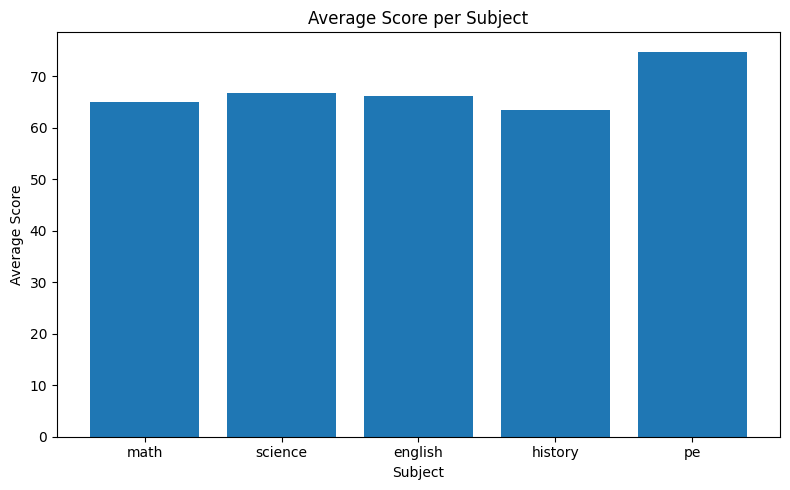

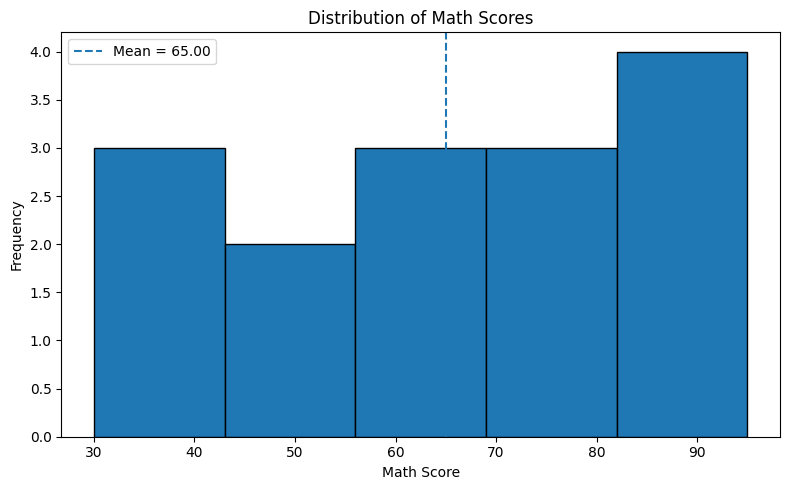

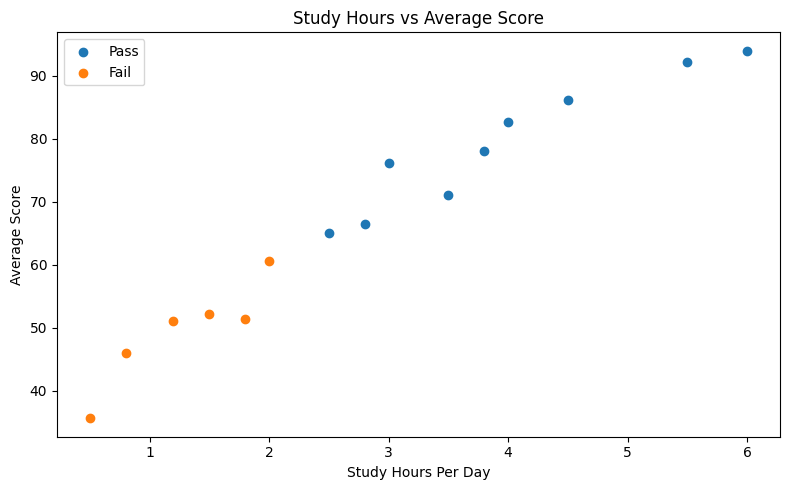

/var/folders/z6/zn2_0qh17kx3_v6l89n_4zpr0000gn/T/ipykernel_82225/3421609605.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])


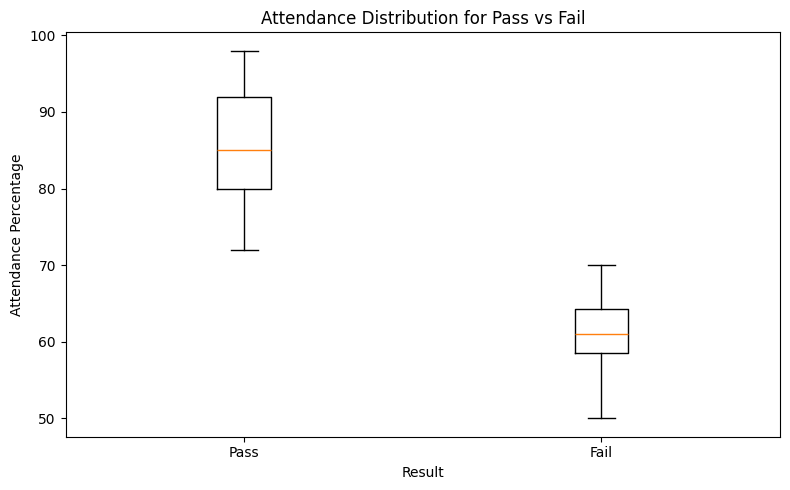

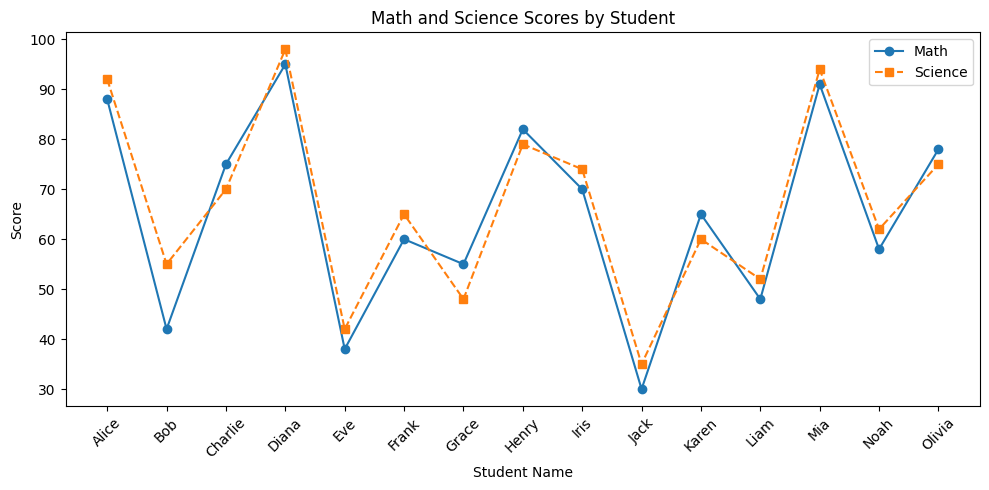

In [ ]:
print("--- TASK 2: VISUALIZATION WITH MATPLOTLIB ---")

# Prepare avg_score column as requested
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# 1. Bar Chart: Avg score per subject
plt.figure(figsize=(8, 5))
plt.bar(subject_cols, df[subject_cols].mean(), color='skyblue', label='Avg Score')
plt.title("Average Score per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot1_bar.png")
plt.show()

# 2. Histogram: Math scores distribution
plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, edgecolor='black', alpha=0.7, color='green', label='Math Scores')
plt.axvline(df['math'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df["math"].mean():.2f}')
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.legend()
plt.savefig("plot2_histogram.png")
plt.show()

# 3. Scatter Plot: Study Hours vs Avg Score
plt.figure(figsize=(8, 5))
plt.scatter(df[df['passed']==1]['study_hours_per_day'], df[df['passed']==1]['avg_score'], color='blue', label='Pass')
plt.scatter(df[df['passed']==0]['study_hours_per_day'], df[df['passed']==0]['avg_score'], color='orange', label='Fail')
plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

# 4. Box Plot: Attendance Pass vs Fail
plt.figure(figsize=(8, 5))
pass_attendance = df[df['passed']==1]['attendance_pct'].tolist()
fail_attendance = df[df['passed']==0]['attendance_pct'].tolist()
plt.boxplot([pass_attendance, fail_attendance], tick_labels=['Pass', 'Fail'])
plt.title("Attendance Distribution: Pass vs Fail")
plt.xlabel("Result")
plt.ylabel("Attendance Percentage")
plt.savefig("plot4_boxplot.png")
plt.show()

# 5. Line Plot: Math and Science scores per student
plt.figure(figsize=(12, 6))
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', linestyle='--', label='Science')
plt.title("Math vs Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()

## Task 3: Data Visualization with Seaborn

Seaborn is used here to create cleaner and more statistically meaningful visualizations.

Compared to Matplotlib, Seaborn requires less code for grouped plots and regression analysis.

The following plots are created:
- Bar plots comparing math and science scores for Pass vs Fail
- Scatter plot with regression lines to analyze attendance vs performance

Matplotlib gives more manual control over each part of the plot.
Seaborn makes statistical plots and grouped visualizations quicker to build.
For these plots, Seaborn needed less code, while Matplotlib felt more flexible for custom formatting.


TASK 3 - DATA VISUALIZATION WITH SEABORN
------------------------------------------------------------


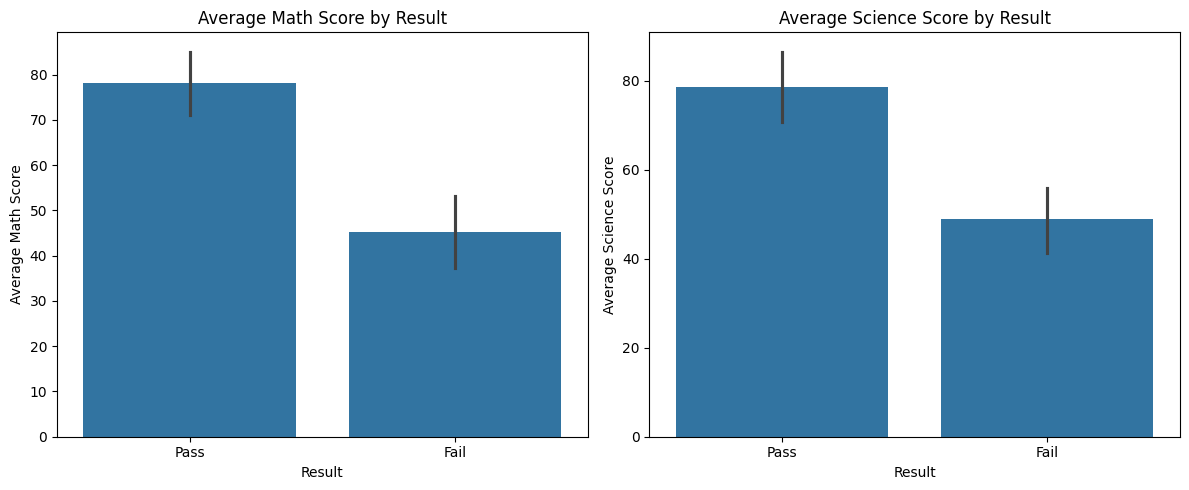

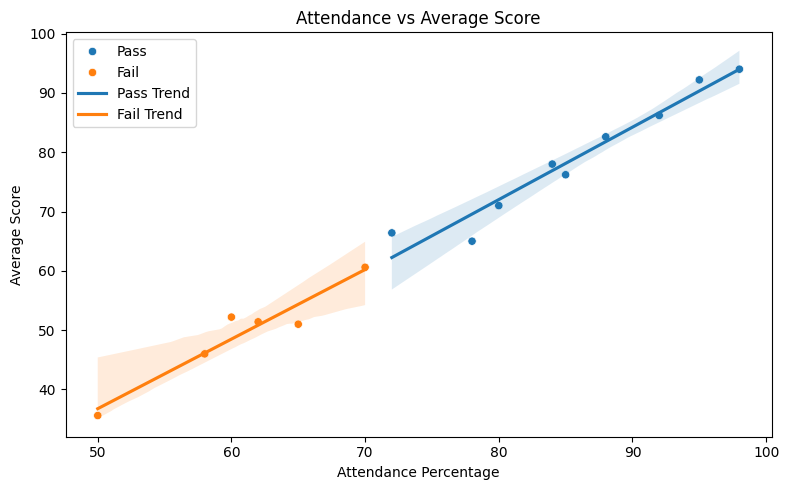

In [ ]:
print("--- TASK 3: VISUALIZATION WITH SEABORN ---")

# 1. Seaborn Bar Plot Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x='passed', y='math', ax=ax1, hue='passed', palette='muted', legend=False)
ax1.set_title("Avg Math Score by Pass/Fail")
sns.barplot(data=df, x='passed', y='science', ax=ax2, hue='passed', palette='muted', legend=False)
ax2.set_title("Avg Science Score by Pass/Fail")
plt.savefig("plot6_seaborn_bar.png")
plt.show()

# 2. Seaborn Scatter with Regression
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed', palette='deep')
sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', scatter=False, label='Pass Trend', color='blue')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', scatter=False, label='Fail Trend', color='red')
plt.title("Attendance vs Average Score with Regression Lines")
plt.legend()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

# --- Comparison Comment ---
# Matplotlib requires more lines of code to handle grouping and manual calculation of lines like regression.
# Seaborn is significantly easier for statistical visualizations as it handles grouping and regression automatically.
# However, Matplotlib is better for granular control over the layout of simple plots.

## Task 4: Machine Learning with Scikit-learn

In this section, a classification model is built to predict whether a student will pass or fail.

The workflow includes:
- preparing the data
- training a model
- evaluating performance
- understanding feature importance
- making predictions for new data

>### Step 1: Data Preparation
>The features (X) and target (y) are separated.
>The dataset is split into training and testing sets (80/20 split).
>Feature scaling is applied using StandardScaler to ensure all features are on the same scale.

>### Step 2: Model Training
>A Logistic Regression model is trained using the scaled training data.
>Training accuracy is calculated to see how well the model fits the training set.

In [ ]:
from sklearn.metrics import accuracy_score
print("--- TASK 4: MACHINE LEARNING ---")

# Step 1: Prepare Data
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Train Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
print(f"Training Accuracy: {train_acc:.2f}")

# Step 3: Evaluate Model
test_preds = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_preds)
print(f"Test Accuracy: {test_acc:.2f}\n")

test_names = df.loc[X_test.index, 'name']
for idx, name in zip(X_test.index, test_names):
    actual = y_test[idx]
    pred = test_preds[list(X_test.index).index(idx)]
    status = "✅ correct" if actual == pred else "❌ wrong"
    print(f"{name}: Actual={actual}, Predicted={pred} -> {status}")


TASK 4 - MACHINE LEARNING WITH SCIKIT-LEARN
------------------------------------------------------------


In [ ]:
model = LogisticRegression() # Initialize the logistic regression model
model.fit(X_train_scaled, y_train) # Train the model on scaled training data

train_predictions = model.predict(X_train_scaled) # Generate predictions for training set
train_accuracy = accuracy_score(y_train, train_predictions) # Calculate training accuracy

print(f"\nTraining Accuracy: {train_accuracy:.2f}") # Display accuracy


Training Accuracy: 1.00


>### Step 3: Model Evaluation
>The model is tested on unseen data (test set).
>Predictions are compared with actual results, and accuracy is calculated.
>Each prediction is displayed along with whether it was correct or incorrect.

In [ ]:
test_predictions = model.predict(X_test_scaled) # Predict results for the unseen test set
test_accuracy = accuracy_score(y_test, test_predictions) # Calculate accuracy on test set

print(f"Test Accuracy: {test_accuracy:.2f}") # Display result

Test Accuracy: 1.00


>### Step 4: Feature Importance
>The model coefficients are extracted to understand which features influence the prediction the most.
>Positive coefficients push the prediction towards "Pass", while negative coefficients push towards "Fail".
>A horizontal bar chart is plotted to visualize feature importance.


Test Set Predictions:
Jack: Actual = Fail, Predicted = Fail -> ✅ correct
Liam: Actual = Fail, Predicted = Fail -> ✅ correct
Alice: Actual = Pass, Predicted = Pass -> ✅ correct

Feature Coefficients (sorted by absolute value):
english              0.8125
attendance_pct       0.5219
study_hours_per_day  0.4844
pe                   0.4750
math                 0.4379
science              0.3230
history              0.2629


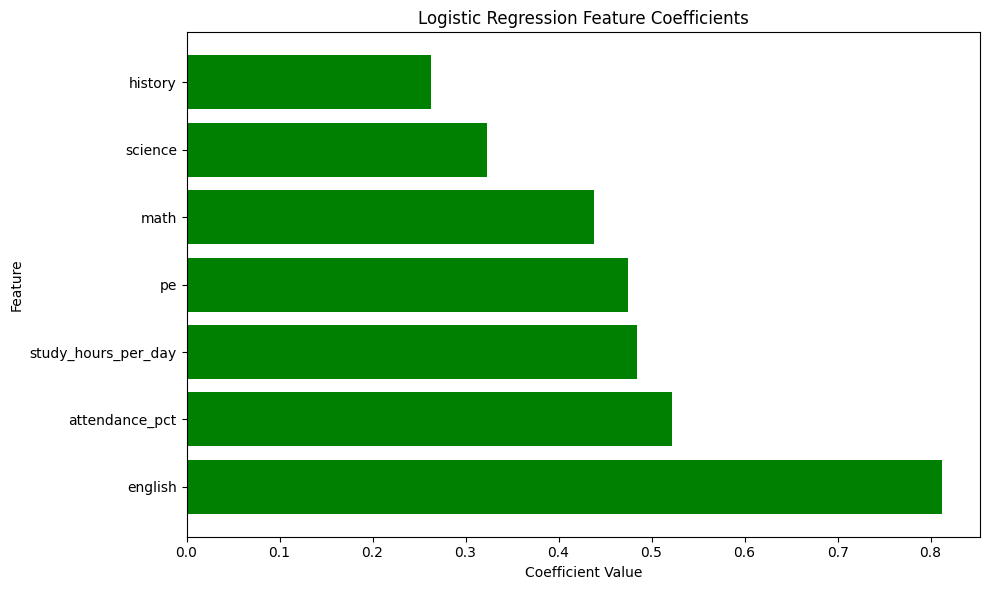

In [ ]:
print("\n--- Step 4: Feature Importance ---")
coeffs = model.coef_[0]
feat_importance = sorted(zip(feature_cols, coeffs), key=lambda x: abs(x[1]), reverse=True)

print("Coefficients (Sorted by absolute value):")
for feat, val in feat_importance:
    print(f"{feat}: {val:.4f}")

# Horizontal Bar Chart
plt.figure(figsize=(10, 6))
sorted_feats = [x[0] for x in feat_importance][::-1]
sorted_vals = [x[1] for x in feat_importance][::-1]
colours = ['green' if v > 0 else 'red' for v in sorted_vals]

plt.barh(sorted_feats, sorted_vals, color=colours)
plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient Value (Impact on Pass/Fail)")
plt.ylabel("Features")
plt.axvline(0, color='black', linewidth=0.8)
plt.savefig("plot8_feature_importance.png")
plt.show()

>### Step 5: Predicting for a New Student
>A new student record is created and passed through the trained model to predict whether they will pass or fail.
>The input is converted into a DataFrame to match the feature names used during training. This avoids warnings and ensures consistency.
>The model outputs:
>- predicted class (Pass/Fail)
>- probability for each class

In [ ]:
print("--- Step 5: Bonus - Predict for a New Student ---")
# math, science, english, history, pe, attendance_pct, study_hours_per_day
new_student_data = [[75, 70, 68, 65, 80, 82, 3.2]]
new_student_scaled = scaler.transform(new_student_data)

pred = model.predict(new_student_scaled)[0]
proba = model.predict_proba(new_student_scaled)[0]

result = "Pass" if pred == 1 else "Fail"
print(f"New Student Values: {new_student_data[0]}")
print(f"Predicted Result: {result}")
print(f"Probability of Failure: {proba[0]:.4f}")
print(f"Probability of Passing: {proba[1]:.4f}")


New Student Prediction:
Predicted Result: Pass
Probability [Fail, Pass]: [0.09203526 0.90796474]
